# The Normal Distribution

The probably most important family of continuous probability distributions is the family of Gaussian or normal distributions. A random variable $X$ is normally distributed with mean $\mu$ and variance $\sigma^2$, denoted by $X \sim \mathrm{N}(\mu, \sigma^2)$, if it follows the density function
$$
p(x) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right) \enspace .
$$

## Basic Form

The general form of the density function of the Gaussian or normal distribution can be overwhelming for beginners, simply because it contains a lot of symbols. However, at its core lies a simple exponentiated quadratic function:
$$
\exp(-x^2) \enspace .
$$
This is not yet a probability density, because it does integrate to 1, but it is proportional to *a* normal distribution, i.e., it is an *unnormalised potential*. Importantly, it already exhibits the characteristic bell-shaped curve.

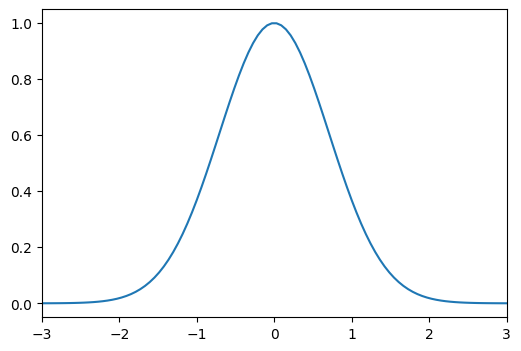

In [7]:
import numpy as np
from matplotlib import pyplot as plt

def g(x):
    return np.exp(-x**2)

_, ax = plt.subplots(figsize=(6, 4))
x = np.linspace(-3, 3, 100)
ax.plot(x, g(x))
ax.margins(x=0)
plt.show()


To turn this function into a proper probability distribution we have to find the normalising constant $$Z=\int_{-\infty}^\infty \exp(-x^2) \, \mathrm{d}x \enspace .$$ 
However, this is difficult to derive, because there is no elementary anti-derivative, and the derivation involves some advanced techniques. We will discuss the proof below for those who are interested and, for now, simply state as elementary result that the normalisation constant is $Z=\sqrt{\pi}$. 
In other words,
$$\frac{1}{\sqrt{\pi}}\exp(-x^2)$$
is a proper probability density that also corresponds to the *a* normal distribution, though not to *the* standard normal distribution, which is calibrated to have a variance of $1$. 

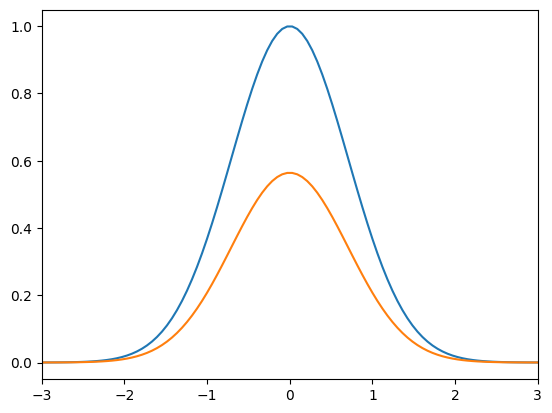

In [41]:
x = np.linspace(-3, 3, 100)
plt.plot(x, g(x))
plt.plot(x, g(x)/np.pi**0.5)
plt.margins(x=0)
plt.show()

To see that the above form does not have a variance of 1, let us first find the corresponding expected value 
$$\mathbb E(X)=\int_{-\infty}^{\infty} \frac{x}{\sqrt\pi} \exp(-x^2) \, \mathrm{d}x \enspace .$$

Simply by plotting the integrand $x \exp(-x^2)$, it is easy to see that the expected value is $0$.

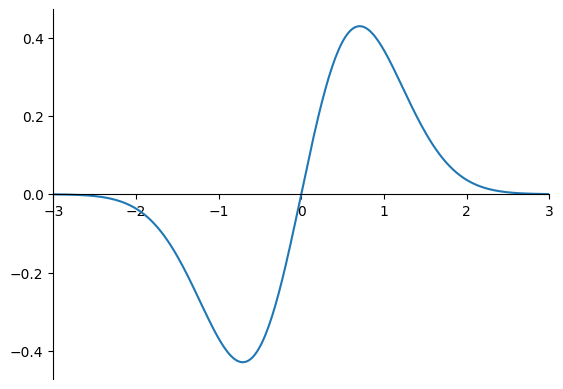

In [ ]:
plt.plot(x, x*g(x))
plt.margins(x=0)
plt.gca().spines['bottom'].set_position('zero')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

We can also derive this result analytically. Though the integrand, $x\exp(-x^2)$, seems on first glance more complicated than the previous $\exp(-x^2)$, is relatively easy to find an anti-derivative for it. Namely, we have
$$\int x \exp(-x^2) \,\mathrm{d}x =-\frac{1}{2}\exp(-x^2) \enspace .$$

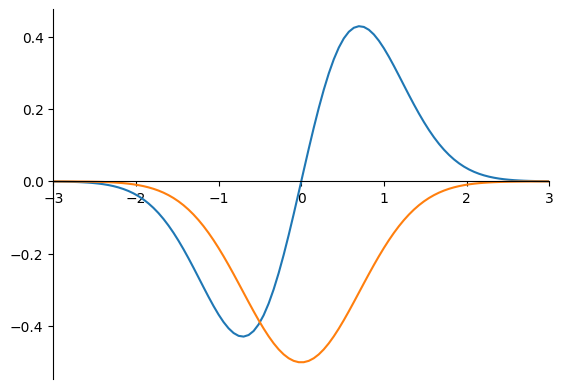

In [43]:
plt.plot(x, x*g(x))
plt.plot(x, -1/2*g(x))
plt.margins(x=0)
plt.gca().spines['bottom'].set_position('zero')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Given that the expected value is $0$, we can now find the variance as 
$$\mathbb{E}X^2 = \frac{1}{\sqrt{\pi}}\int_{-\infty}^\infty x^2 \exp(-x^2) \, \mathrm{d} x \enspace .$$

To solve this integral, we can rewrite the integrand as a product
$$x \cdot x\exp(-x^2)$$
and observe that the right-hand term is again the simple to integrate function we encountered for the expected value. This allows us to use integration by parts

$$
\begin{aligned}
\int_{-\infty}^\infty x^2 \exp(-x^2)\,\mathrm{d}x&=\left[-\frac{1}{2}x \exp(-x^2)\right]_{-\infty}^\infty - \int_{-\infty}^\infty -\frac{1}{2}\exp(-x^2) \, \mathrm{d}x\\
&=\frac{1}{2}\int_{-\infty}^\infty \exp(-x^2) \, \mathrm{d}x\\
&=\frac{1}{2} \sqrt{\pi}
\end{aligned}
$$

Dividing by the normalising constant $\sqrt{\pi}$ then reveals that $\mathbb E X^2=1/2$.


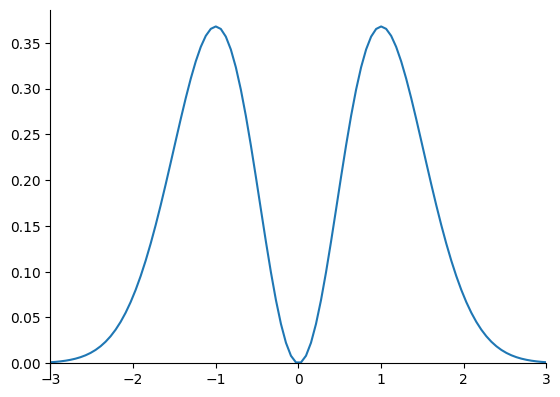

In [44]:
plt.plot(x, x**2*g(x))
plt.margins(x=0)
plt.gca().spines['bottom'].set_position('zero')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

## Standard Form

Knowing that the normal random variable $X$ with pdf $p(x)=\exp(-x^2)/\sqrt{\pi}$ has $\mathbb E X=0$ and $\mathbb V X=1/2$, we can find the pdf for the normal random variable with mean $\mu$ and variance $\sigma^2$ by transforming $X$ into $\sqrt{2} \sigma X + \mu$. Indeed by the properties of expectation and variance we have

$$
\begin{aligned}
\mathbb E(\sqrt 2\sigma X + \mu) &= \sqrt 2\sigma\mathbb{E}X + \mathbb{\mu} = \mu\\
\mathbb V(\sqrt 2\sigma X + \mu) &= 2\sigma^2 \mathbb V X = \sigma^2
\end{aligned}
$$

To find the cdf $F_{\sqrt 2 \sigma X + \mu}$ of $\sqrt 2 \sigma X + \mu$ in terms of the cdf $F_X$ of $X$, we can simply plug in and re-arrange:
$$
\begin{aligned}
F_{\sqrt 2 \sigma X + \mu}(x) &= \Pr(\sqrt 2 \sigma X + \mu \leq x)\\
&= \Pr\left(X \leq \frac{x-\mu}{\sqrt 2 \sigma}\right)\\
&= F_X\left(\frac{x-\mu}{\sqrt 2\sigma}\right)
\end{aligned}
$$

Then we can find the pdf $f_{\sqrt 2 \sigma X + \mu}$ of $\sqrt 2 \sigma X + \mu$ by forming the derivative of the cdf:
$$
\begin{aligned}
f_{\sqrt 2 \sigma X + \mu}(x) &= \frac{\mathrm d}{\mathrm dx} F_{\sqrt 2 \sigma X + \mu}(x)\\
&= \frac{\mathrm d}{\mathrm dx} F_X\left(\frac{x-\mu}{\sqrt 2\sigma}\right)\\
&= \frac{1}{\sqrt 2 \sigma} \frac{\mathrm d}{\mathrm d (x-\mu)/\sqrt{2\sigma^2}} F_X\left(\frac{x-\mu}{\sqrt 2\sigma}\right)\\
&= \frac{1}{\sqrt 2 \sigma} f_X\left(\frac{x-\mu}{\sqrt 2 \sigma}\right)
\end{aligned}
$$

Plugging in the details of $f_X$, we end up with
$$
p(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi}\sigma}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$
as pdf for the normal distribution with mean $\mu$ and variance $\sigma^2$. For a corresponding random variable, we also write 
$$
X \sim \mathrm{N}(\mu, \sigma^2) \enspace .
$$

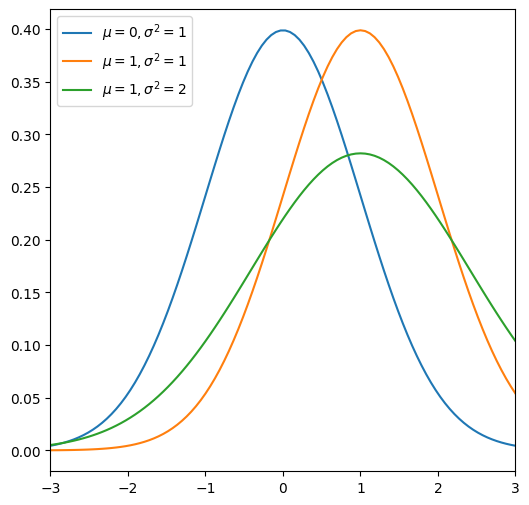

In [16]:
def normal_pdf(x, mu=0, sig2=1):
    return np.exp(-(x-mu)**2/(2*sig2))/(2*np.pi*sig2)**0.5

fig, ax = plt.subplots(figsize=(6, 6))
ax.margins(x=0)
ax.plot(x, normal_pdf(x), label=r'$\mu=0, \sigma^2=1$')
ax.plot(x, normal_pdf(x, 1), label=r'$\mu=1, \sigma^2=1$')
ax.plot(x, normal_pdf(x, 1, 2), label=r'$\mu=1, \sigma^2=2$')
ax.legend()
plt.show()

## Proof of Normalisation Constant

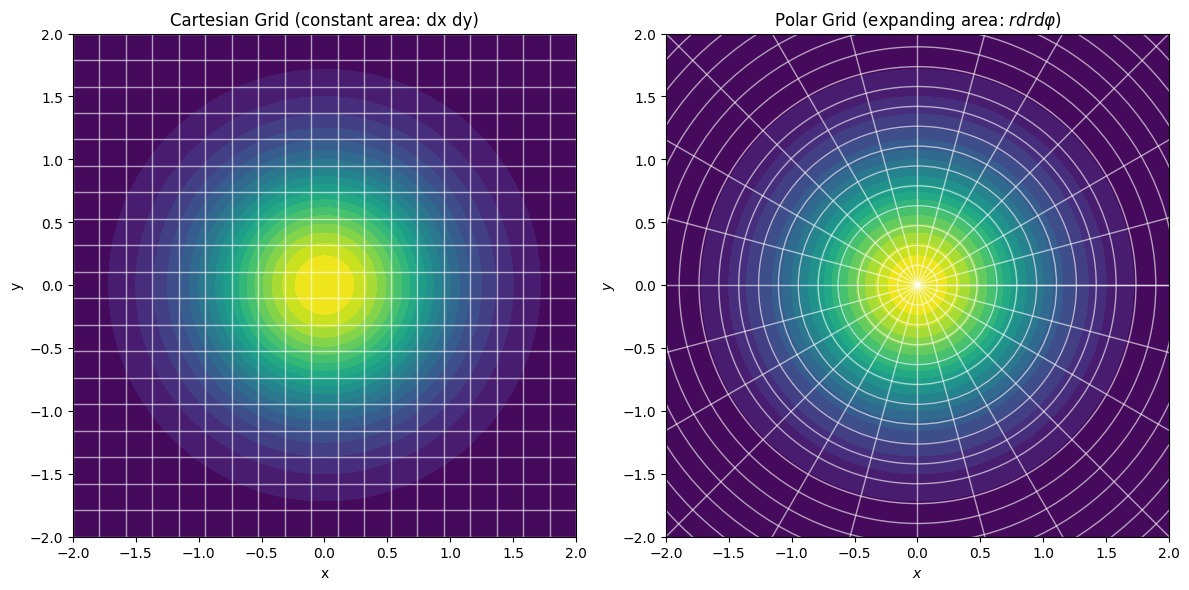

In [45]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)
Z = np.exp(-(X**2 + Y**2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
levels = np.linspace(0.0001, 1.0, 20)

ax1.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=1)

grid_ticks = np.linspace(-2, 2, 20)
for tick in grid_ticks:
    ax1.axvline(tick, color='white', lw=1, alpha=0.6)
    ax1.axhline(tick, color='white', lw=1, alpha=0.6)

ax1.set_title("Cartesian Grid (constant area: dx dy)")
ax1.set_aspect('equal')
ax1.set_xlim(-2, 2)
ax1.set_ylim(-2, 2)
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# --- Subplot 2: Polar Grid ---
ax2.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=1)

# Overlay Polar grid lines (r, phi)
radii = np.linspace(0, 3, 20)
angles = np.linspace(0, 2 * np.pi, 25)

# Draw concentric circles (constant r)
for r in radii:
    circle = plt.Circle((0, 0), r, color='white', fill=False, lw=1, alpha=0.6)
    ax2.add_patch(circle)

# Draw radial rays (constant phi)
for angle in angles:
    ax2.plot([0, 4 * np.cos(angle)], [0, 4 * np.sin(angle)], color='white', lw=1, alpha=0.6)

ax2.set_title(r"Polar Grid (expanding area: $r dr d\varphi$)")
ax2.set_aspect('equal')
ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')

plt.tight_layout()
plt.show()